# 18 - Born-fraction nodes across κ

Notebook 17 recommended `accdm_q_log_share = 0.25` at the chains' transition (κ = 12.1). This repeats
notebook 12's κ sweep with it (a_t = 0.09, m = 10¹¹ GeV, f_acc = 0.01, κ = 2–290, no sink). The even
grid's runs are read from `12_cache.pkl`.

**Result.** s = 0.25 holds across κ.
- 37–43 of 51 nodes sit inside the births at every κ; the even grid drops to one node from κ = 150.
- Two references, the even grid at 801 bins and s = 0.25 at 401, agree to Δχ² ≤ 1.3·10⁻³ at every κ
  (apart from two 0.041 jumps); at large κ the s = 0.25 reference is the better one.
- With 51 bins, s = 0.25 stays at Δχ² ≤ 0.05 up to κ = 290, where the even grid exceeds 0.1 from κ = 50
  (450 at κ = 100). The 51-bin born-fraction grid covers more than the 401-bin even grid did.
- The P_cb tolerance (10⁻³) holds to κ = 50 at 51 bins (even: 30), 75 at 101 and 100 at 201. Above κ ≈ 100
  a near-constant 1–6·10⁻³ P_cb offset remains, shrinking slowly with bins and changing sign — not a lack
  of nodes in the window. At κ ≥ 250 the two references themselves differ by 0.5–1.3·10⁻³.
- The default 50/decade count (55 nodes at large κ) does worse at κ ≥ 150 than 51 explicit bins
  (Δχ² 0.07–0.26 against ≤ 0.04): the large-κ error is not monotonic in the node count.

Open: the P_cb offset above κ ≈ 100, the non-monotonic node-count dependence at κ ≥ 150, and the 0.04
jumps. New runs cached in `18_cache.pkl`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import (LITE_LIN_11, LCDM_LITE_LIN_11, RunCache, a_min, born_fraction, chi2_parts, node_lna, ok,
                      q_size, show, status, plot_style)

plot_style()

A_T, F_ACC, F_NULL, S = 0.09, 1e-2, 1e-6, 0.25
KAPPAS = [2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200, 250, 290]
DCHI2_TOL, PK_TOL = 0.1, 1e-3
SETTINGS = {**LITE_LIN_11, 'a_t_acc': A_T, 'acc_de_sink': 'no', 'ncdm_quadrature_strategy': '0, 5'}


def bins(n):
    return {'ncdm_N_momentum_bins': '15, {:d}'.format(n)}


SETUPS = {'even 51': bins(51), 'even 101': bins(101), 'even 201': bins(201), 'even 401': bins(401),
          'even 801': bins(801), 'even 50/dec': {},
          's.25 51': {**bins(51), 'accdm_q_log_share': S}, 's.25 101': {**bins(101), 'accdm_q_log_share': S},
          's.25 201': {**bins(201), 'accdm_q_log_share': S}, 's.25 401': {**bins(401), 'accdm_q_log_share': S},
          's.25 50/dec': {'accdm_q_log_share': S}}
REFS = ('even 801', 's.25 401')


def params(kappa, lab, f_acc=F_ACC):
    return {**LCDM_LITE_LIN_11, **SETTINGS, **SETUPS[lab], 'kappa_acc': float(kappa), 'f_acc': f_acc}

## 0. Nodes in the birth window

In [2]:
rows = []
for k in KAPPAS:
    amin = a_min(k, A_T)
    row = {'kappa': k, 'a_min': amin}
    for lab, share, n in [('even 51', 1, 51), ('even 801', 1, 801), ('s.25 51', S, 51), ('s.25 50/dec', S, None)]:
        F = born_fraction(np.exp(node_lna(n or q_size(50, amin), share, k, A_T)), k, A_T)
        row[lab] = '{}/{}'.format(len(F), int(np.sum((F > 0.01) & (F < 0.99))))
    rows.append(row)
print('bins / nodes in 1–99% of births')
show(pd.DataFrame(rows).set_index('kappa'), {'a_min': '{:.2e}'})

bins / nodes in 1–99% of births


,a_min,even 51,even 801,s.25 51,s.25 50/dec
kappa,,,,,
2,8.96e-05,51/23,801/370,51/43,205/174
3,9.00e-04,51/22,801/347,51/43,155/129
5,5.68e-03,51/18,801/284,51/42,115/93
8,1.60e-02,51/14,801/223,51/41,91/73
12,2.85e-02,51/11,801/172,51/39,79/62
20,4.51e-02,51/7,801/118,51/38,69/52
30,5.68e-02,51/5,801/86,51/38,65/48
50,6.83e-02,51/3,801/55,51/37,61/45
75,7.49e-02,51/2,801/38,51/38,59/43


## 1. Stability against both references

Symbols as notebook 12: `.` stable, `X` Δχ² > 0.1, `P` max |ΔP_cb/P_cb| > 10⁻³, `E` CLASS error, `=` the
reference itself.

In [3]:
cache = RunCache('18_cache.pkl', also=['12_cache.pkl'], timeout=900)
null = cache(params(5, 'even 51', F_NULL))
res = dict(zip([(lab, k) for k in KAPPAS for lab in SETUPS],
               cache.many([params(k, lab) for k in KAPPAS for lab in SETUPS])))


def compare(lab, k, base):
    a, b = res[(lab, k)], res[(base, k)]
    if not (ok(a) and ok(b)):
        return None
    return {'dchi2': chi2_parts(a, b)['total'], 'dpk': float(np.max(np.abs(a['pk_cb']/b['pk_cb'] - 1)))}


def verdict(lab, k, base):
    if lab == base:
        return '='
    if not ok(res[(lab, k)]):
        return 'E'
    c = compare(lab, k, base)
    return '?' if c is None else 'X' if c['dchi2'] > DCHI2_TOL else 'P' if c['dpk'] > PK_TOL else '.'


for base in REFS:
    print('\nagainst', base)
    print('{:>6}'.format('kappa') + ''.join('{:>12}'.format(lab) for lab in SETUPS))
    for k in KAPPAS:
        print('{:>6g}'.format(k) + ''.join('{:>12}'.format(verdict(lab, k, base)) for lab in SETUPS))


against even 801
 kappa     even 51    even 101    even 201    even 401    even 801 even 50/dec     s.25 51    s.25 101    s.25 201    s.25 401 s.25 50/dec
     2           .           .           .           .           =           .           .           .           .           .           .
     3           .           .           .           .           =           .           .           .           .           .           .
     5           .           .           .           .           =           .           .           .           .           .           .
     8           .           .           .           .           =           .           .           .           .           .           .
    12           .           .           .           .           =           .           .           .           .           .           .
    20           .           .           .           .           =           .           .           .           .           .           .
    30   

   250           X           X           X           P           =           X           P           P           P           .           P
   290           X           X           X           X           =           X           P           P           P           P           X

against s.25 401
 kappa     even 51    even 101    even 201    even 401    even 801 even 50/dec     s.25 51    s.25 101    s.25 201    s.25 401 s.25 50/dec
     2           .           .           .           .           .           .           .           .           .           =           .
     3           .           .           .           .           .           .           .           .           .           =           .
     5           .           .           .           .           .           .           .           .           .           =           .


     8           .           .           .           .           .           .           .           .           .           =           .
    12           .           .           .           .           .           .           .           .           .           =           .
    20           .           .           .           .           .           .           .           .           .           =           .
    30           X           .           .           .           .           P           .           .           .           =           .
    50           X           P           .           .           .           X           .           .           .           =           .
    75           X           X           .           .           .           X           P           .           .           =           P
   100           X           X           P           .           .           X           P           P           .           =           P
   150           X         

## 2. Δχ² in numbers

,signal,even 51 vs even 801,s.25 51 vs even 801,s.25 51 vs s.25 401,s.25 101 vs s.25 401,s.25 201 vs s.25 401,s.25 50/dec vs s.25 401,even 401 vs even 801,even 801 vs s.25 401
kappa,,,,,,,,,
2,5.6e+01,4.3e-04,1.0e-04,1.0e-04,5.2e-05,8.0e-06,1.1e-05,2.3e-06,1.2e-06
3,5.8e+01,4.2e-02,1.0e-04,1.1e-04,8.8e-06,4.1e-02,3.8e-06,4.1e-02,1.6e-06
5,5.9e+01,4.4e-04,2.6e-05,2.3e-05,1.2e-06,9.7e-07,1.2e-06,4.1e-02,2.0e-07
8,5.9e+01,4.2e-02,4.1e-02,8.2e-05,4.1e-02,2.9e-08,3.0e-06,4.1e-02,4.1e-02
12,5.9e+01,4.2e-04,6.6e-05,6.5e-05,7.1e-07,2.1e-07,1.9e-06,1.4e-06,7.1e-08
20,5.9e+01,1.5e-03,1.5e-04,1.6e-04,4.1e-02,2.2e-07,4.1e-02,1.3e-07,8.4e-07
30,5.9e+01,7.0e-02,1.3e-03,4.3e-02,4.1e-02,4.1e-02,4.2e-02,4.9e-07,4.1e-02
50,5.9e+01,2.0e+00,8.0e-03,8.0e-03,4.3e-04,2.8e-06,2.4e-03,3.8e-07,1.6e-07
75,5.9e+01,8.5e+00,3.5e-02,3.5e-02,2.1e-04,2.1e-05,4.6e-02,2.8e-07,3.4e-07


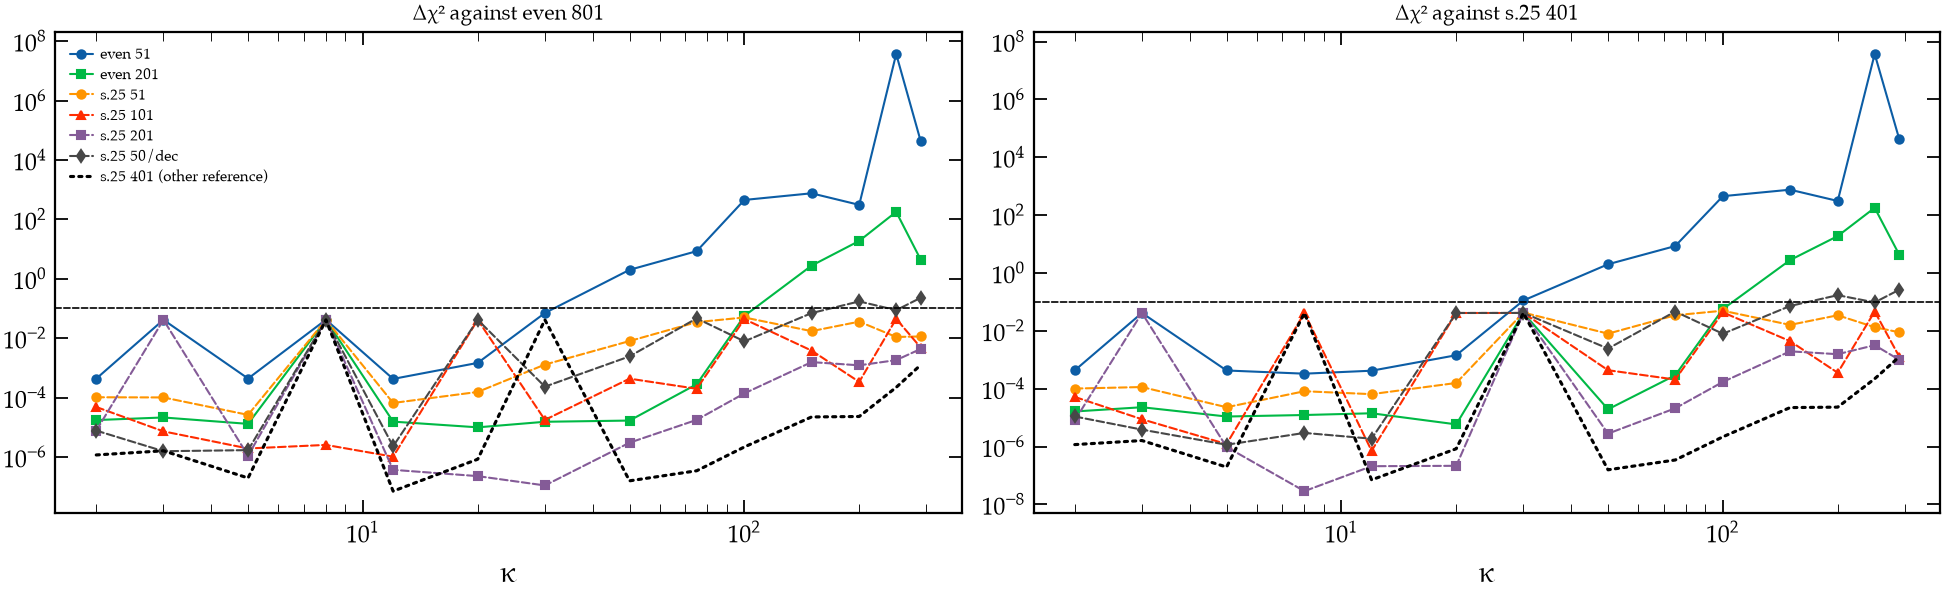

In [4]:
PAIRS = [('even 51', REFS[0]), ('s.25 51', REFS[0]), ('s.25 51', REFS[1]), ('s.25 101', REFS[1]),
         ('s.25 201', REFS[1]), ('s.25 50/dec', REFS[1]), ('even 401', REFS[0]), (REFS[0], REFS[1])]
rows = []
for k in KAPPAS:
    row = {'kappa': k, 'signal': chi2_parts(res[(REFS[0], k)], null)['total']}
    for lab, base in PAIRS:
        c = compare(lab, k, base)
        row['{} vs {}'.format(lab, base)] = np.nan if c is None else c['dchi2']
    rows.append(row)
show(pd.DataFrame(rows).set_index('kappa'), default='{:.1e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, base in zip(axes, REFS):
    for lab, st in [('even 51', 'o-'), ('even 201', 's-'), ('s.25 51', 'o--'), ('s.25 101', '^--'),
                    ('s.25 201', 's--'), ('s.25 50/dec', 'd--')]:
        pts = [(k, compare(lab, k, base)) for k in KAPPAS]
        pts = [(k, max(c['dchi2'], 1e-12)) for k, c in pts if c]
        ax.loglog(*zip(*pts), st, ms=4, lw=1, label=lab)
    other = REFS[1] if base == REFS[0] else REFS[0]
    pts = [(k, max(compare(other, k, base)['dchi2'], 1e-12)) for k in KAPPAS if compare(other, k, base)]
    ax.loglog(*zip(*pts), 'k:', lw=1.5, label='{} (other reference)'.format(other))
    ax.axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
    ax.set_title('Δχ² against {}'.format(base), fontsize=10)
    ax.set_xlabel('κ')
axes[0].legend(fontsize=7)
plt.show()